In [1]:
import os
import torch
import matplotlib.pyplot as plt

from src.concaves.log import LogConcave

from src.diffeomorphisms.composition import CompositionDiffeomorphism
from src.diffeomorphisms.vector.star import StarVectorDiffeomorphism
from src.diffeomorphisms.vector.concave import ConcaveVectorDiffeomorphism

from archetypes import AA

from src.manifolds.euclidean.vector.pullback.standard import StandardPullbackVectorEuclidean
from src.manifolds.isometrized_euclidean.vector import l2IsometrizedVectorEuclidean

# from src.star_construction import StarConstruction

# settings
n_clusters = 4

# results folder
results_folder = os.path.join("results", "tree", "multi_ellipsoidal_star", "{}_clusters".format(n_clusters))
os.makedirs(results_folder, exist_ok=True)

# set random seed
torch.manual_seed(0)

Using NumPy backend


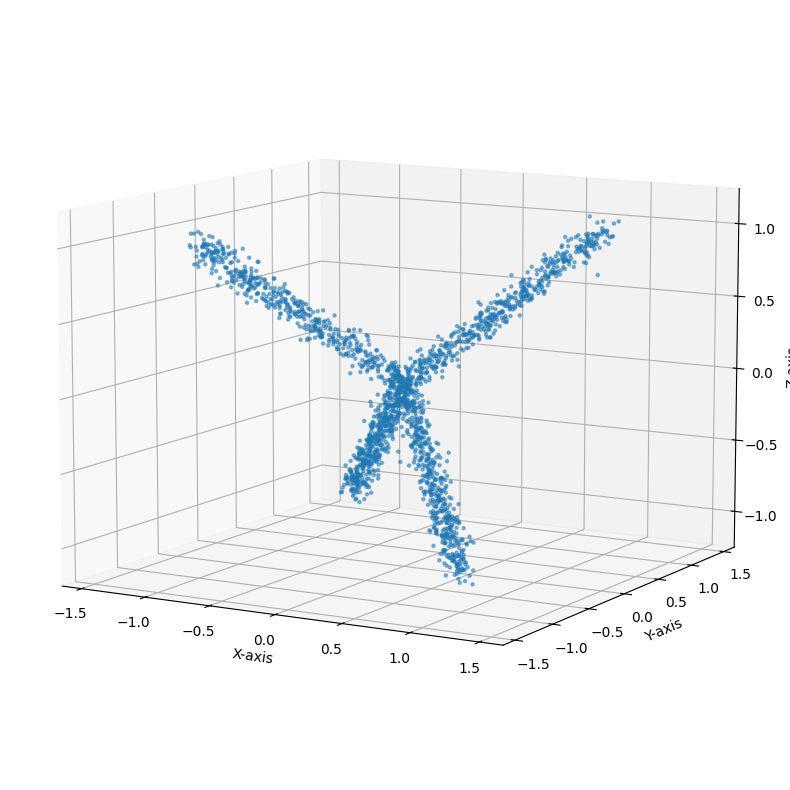

In [2]:
# construct data set from the four corners of a tetrahedron in R3
# construct tetrahedron corners
data_clusters = torch.tensor([[1.0, 1.0, 1.0],
                              [1.0, -1.0, -1.0],
                              [-1.0, 1.0, -1.0],
                              [-1.0, -1.0, 1.0]])

# generate data 
num_data_per_cluster = 500
sigma = 0.05
data = []
for center in data_clusters:
    for _ in range(num_data_per_cluster):
        t = torch.rand(1)
        point = t * center + (1 - t) * torch.zeros(3)
        point += sigma * torch.randn(3)  # small Gaussian noise
        data.append(point)
data = torch.stack(data)

# plot data in 3D
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:, 0], data[:, 1], data[:, 2], s=5, alpha=0.5)
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.axis('equal')
ax.view_init(elev=10)
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"data.png"))
plt.show()

## Learn Star ##

In [5]:
aa = AA(4, init='furthest_sum')
aa.fit(data)
archetypes = aa.archetypes_
labels = torch.tensor(aa.labels_)

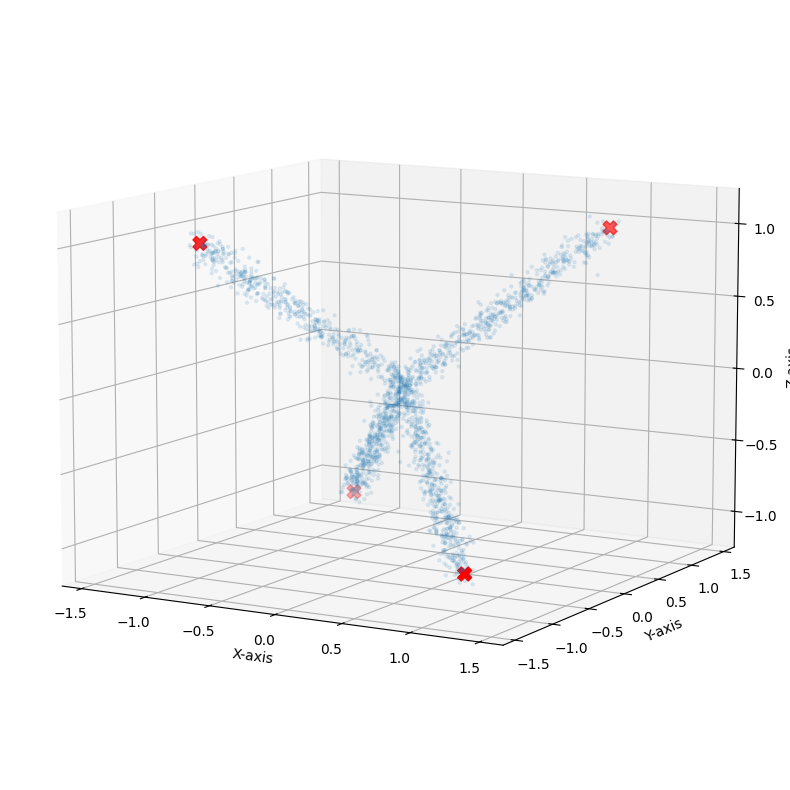

In [6]:
# plot data in 3D
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:, 0], data[:, 1], data[:, 2], s=5, alpha=0.1)
ax.scatter(archetypes[:, 0], archetypes[:, 1], archetypes[:, 2], s=100, c='red', marker='X', label='End Members')
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.axis('equal')
ax.view_init(elev=10)
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"data+end_members.png"))
plt.show()

In [ ]:
trainer = StarConstruction(n_clusters=4, n_archetypes=1, trimmed=True)
trainer.fit(data)

star = trainer.star

NameError: name 'StarConstruction' is not defined

In [ ]:
# generate samples from the distribution
num_samples = 1000
samples = star.sample(num_samples)

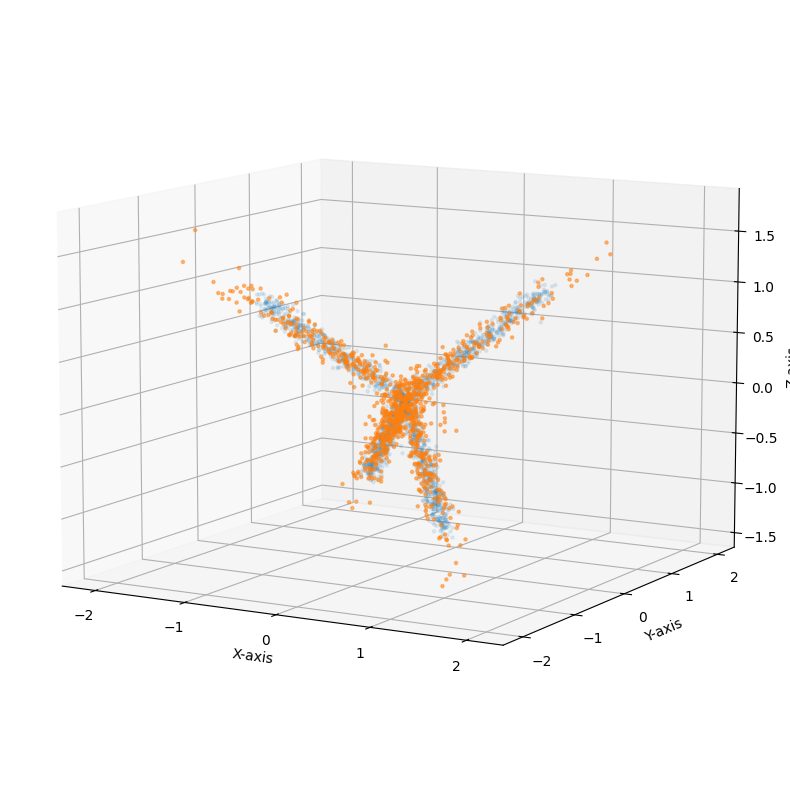

In [ ]:
# plot data in 3D
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:, 0], data[:, 1], data[:, 2], s=5, alpha=0.1)
ax.scatter(samples[:, 0], samples[:, 1], samples[:, 2], s=5, alpha=0.5,)
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.axis('equal')
ax.view_init(elev=10)
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"data+samples.png"))
plt.show()

In [ ]:
phi = StarVectorDiffeomorphism(3, star)
psi = ConcaveVectorDiffeomorphism(3, LogConcave(a=10.))
Phi = CompositionDiffeomorphism([phi, psi])

manifold = StandardPullbackVectorEuclidean(Phi)
iso_manifold = l2IsometrizedVectorEuclidean(manifold, num_intervals=20)

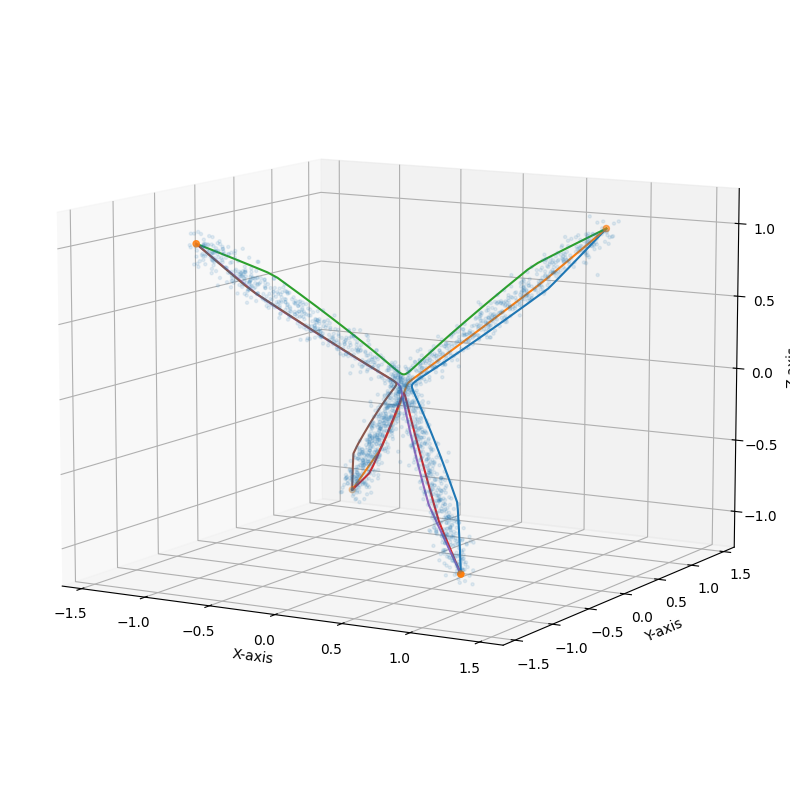

In [ ]:
# compute geodesics between all pairs of points
t = torch.linspace(0, 1, steps=100)
with torch.no_grad():
    geodesics = manifold.geodesic(data_clusters[None], data_clusters[None], t)[0]

# plot geodesics
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
# plot data points
ax.scatter(data[:, 0].numpy(), data[:, 1].numpy(), data[:, 2].numpy(), s=5, alpha=0.1, label='Original Data')
for i in range(data_clusters.shape[0]): 
    for j in range(i + 1, data_clusters.shape[0]):
        ax.plot(geodesics[i, j, :, 0].numpy(), geodesics[i, j, :, 1].numpy(), geodesics[i, j, :, 2].numpy())
ax.scatter(data_clusters[:, 0].numpy(), data_clusters[:, 1].numpy(), data_clusters[:, 2].numpy())
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.axis('equal')
ax.view_init(elev=10)
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"data_geodesics.png"))
plt.show()